##Git and Drive Integration

In [2]:
from __future__ import print_function
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import time

### Mount google drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Clone the assignment repository

In [ ]:
# Clone repository in google drive
%mkdir /content/drive/MyDrive/ece5545
%cd /content/drive/MyDrive/ece5545
!git clone https://<githubtoken>@github.com/aoyangchen/ECE5545-ML-Hardware-Systems.git #paste your github token here

/content/drive/MyDrive/ece5545
Cloning into 'ECE5545-ML-Hardware-Systems'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 141 (delta 3), reused 0 (delta 0), pack-reused 128
Receiving objects: 100% (141/141), 19.48 MiB | 10.78 MiB/s, done.
Resolving deltas: 100% (17/17), done.
Updating files: 100% (107/107), done.


### Add `src` directory to the Python import path

In [4]:
# import functions from the src directory in repo
import sys
sys.path.insert(0, '/content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0/src')

### Import functions from `src/train_utils.py`

In [5]:
import train_utils
from model import *

### Make changes to `src` files and push to repo

In [9]:
# You will likely need to set your git user identification settings
!git config --global user.email ""  # update with your email
!git config --global user.name "aoyangchen"   # update with your name

In [ ]:
!git config --global --get user.email
!git config --global --get user.name


In [14]:
# To run the same tests that are run on Github Classroom
%cd /content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0
!python3 -m pytest

/content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0
======================================= test session starts ========================================
platform linux -- Python 3.10.12, pytest-7.4.4, pluggy-1.5.0
rootdir: /content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0
plugins: anyio-3.7.1
collected 1 item                                                                                   

tests/test_model.py .                                                                        [100%]

======================================== 1 passed in 3.01s =========================================


In [19]:
!sudo apt-get install git


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.11).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [ ]:
!git remote -v


In [23]:
!git pull origin main


From https://github.com/aoyangchen/ECE5545-ML-Hardware-Systems
 * branch            main       -> FETCH_HEAD
Already up to date.


In [33]:
%cd /content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0/src
# Navigate to a0/src/model.py and fix the bug (denoted by TODO)
# in the file then commit the changes below
!git add .
!git commit -am "model.py"
!git push origin main


# Add the untracked files
!git add ../a0.ipynb ../tests/__pycache__

# Commit the changes
!git commit -m "Add untracked files"

# Push the changes to the remote repository
!git push origin main

/content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0/src
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	../a0.ipynb
	../tests/__pycache__/

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date
[main d48484a] Add untracked files
 2 files changed, 1 insertion(+)
 create mode 100644 a0/a0.ipynb
 create mode 100644 a0/tests/__pycache__/test_model.cpython-310-pytest-7.4.4.pyc
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 16.45 KiB | 765.00 KiB/s, done.
Total 7 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
remote: error: GH013: Repository rule violations found for refs/heads/main.
remote: 
remote: - GITHUB PUSH PROTECTION
remote:   ——————————————

In [11]:
# Navigate to the repository directory
%cd /content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0

# Reset the last commit (make sure you have cleaned a0.ipynb)
!git reset HEAD~4

# Stage the correct files
!git add a0.ipynb src/__pycache__ tests/__pycache__

# Commit the changes
!git commit -m "Reset"

# Force push the changes to the remote repository
!git push --force origin main


/content/drive/MyDrive/ece5545/ECE5545-ML-Hardware-Systems/a0
Unstaged changes after reset:
M	a0/a0.ipynb

It took 20.04 seconds to enumerate unstaged changes after reset.  You can
use '--quiet' to avoid this.  Set the config setting reset.quiet to true
to make this the default.
[main 3f2f9b0] Reset
 4 files changed, 1 insertion(+), 510 deletions(-)
 rewrite a0/a0.ipynb (100%)
 create mode 100644 a0/src/__pycache__/model.cpython-310.pyc
 create mode 100644 a0/src/__pycache__/train_utils.cpython-310.pyc
 create mode 100644 a0/tests/__pycache__/test_model.cpython-310-pytest-7.4.4.pyc
Enumerating objects: 16, done.
Counting objects: 100% (16/16), done.
Delta compression using up to 2 threads
Compressing objects: 100% (11/11), done.
Writing objects: 100% (11/11), 8.21 KiB | 247.00 KiB/s, done.
Total 11 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/aoyangchen/ECE5545-ML-Hardware-Systems.git
 + 7b3628b.

## Training Configuration

In [12]:
batch_size = 256
epochs = 5
lr = 1.0
gamma = 0.7
no_cuda = False
seed = 42
log_interval = 50
save_model = False
dry_run = False

# Derived parameters
use_cuda = not no_cuda and torch.cuda.is_available()
torch.manual_seed(seed)
device = torch.device("cuda" if use_cuda else "cpu")

train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': batch_size}
if use_cuda:
    cuda_kwargs = {'num_workers': 1,
                   'pin_memory': True,
                   'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

## Data Loaders and Optimizer Setup

In [13]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    ])
dataset1 = datasets.MNIST('/content/drive/MyDrive/ece5545/data', train=True, download=True,
                    transform=transform)
dataset2 = datasets.MNIST('/content/drive/MyDrive/ece5545/data', train=False,
                       transform=transform)
train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

model = Net().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=lr)

scheduler = StepLR(optimizer, step_size=1, gamma=gamma)

## Training Loop

In [14]:
import importlib
importlib.reload(train_utils)
# we use importlib to make sure that we are loading
# the latest version of train_utils after any changes
# that you may have done

for epoch in range(1, epochs + 1):
    train_utils.train(model, device, train_loader, optimizer, epoch, log_interval, dry_run)
    train_utils.test(model, device, test_loader)
    scheduler.step()

if save_model:
    torch.save(model.state_dict(), "mnist_cnn.pt")

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.305827
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.342576
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.168907
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.163755
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.144281

Epoch 1 time = 18.02s on device cuda

Test set: Average loss: 0.0554, Accuracy: 9824/10000 (98%)

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.112146
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.092053
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.093338
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.074772
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.097185

Epoch 2 time = 16.59s on device cuda

Test set: Average loss: 0.0350, Accuracy: 9878/10000 (99%)

Train Epoch: 3 [0/60000 (0%)]	Loss: 0.046744
Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.034865
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.026205
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.066868
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.076938

Epoch 3 time = 16.53s on device cuda

Test set: Average loss: 0.03

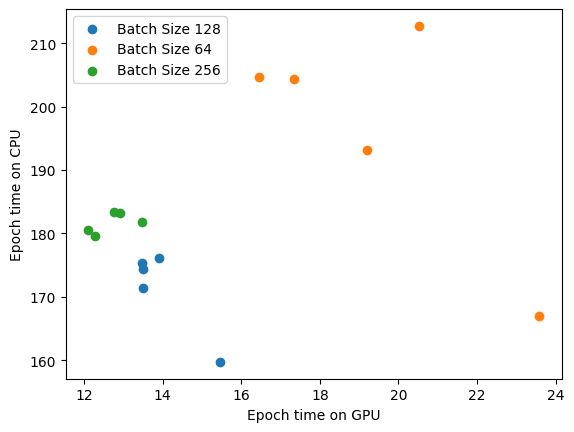

In [15]:
import matplotlib.pyplot as plt
%matplotlib inline
gpu_bs_128 = [15.45, 13.51, 13.91, 13.49, 13.47]
cpu_bs_128 = [159.73, 171.38, 176.2, 174.39, 175.4]
gpu_bs_64 = [23.58, 19.21, 16.44, 17.35, 20.51]
cpu_bs_64 = [167.01, 193.13, 204.67, 204.43, 212.74]
gpu_bs_256 = [12.76, 12.11, 12.92, 12.27, 13.47]
cpu_bs_256 = [183.39, 180.52, 183.26, 179.67, 181.88]

bs_128 = plt.scatter(gpu_bs_128, cpu_bs_128)
bs_64 = plt.scatter(gpu_bs_64, cpu_bs_64)
bs_256 = plt.scatter(gpu_bs_256, cpu_bs_256)
plt.xlabel('Epoch time on GPU')
plt.ylabel('Epoch time on CPU')
plt.legend((bs_128, bs_64, bs_256),
           ('Batch Size 128', 'Batch Size 64', 'Batch Size 256'))
plt.show()

In [16]:
# Diagnostic information about the used GPU device
!nvidia-smi

Wed Jun 12 23:27:09 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   76C    P0              34W /  70W |    495MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
# Stage the correct files
!git add .

# Commit the changes
!git commit -m "Full run"

# Force push the changes to the remote repository
!git push --force origin main
